# Case Study: Bayesian logistic regression with a Laplace prior via SOUL with PAIES step and the walk move (emcee).

In [3]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))  
sys.path.append(project_root)

import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
from algorithms import sig, log_p_laplace, so_walk_fast_decay
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

os.chdir(project_root)

# Obtain synthetic dataset for Laplace prior case

In [4]:
from scipy.stats import laplace, bernoulli
# Data and design matrix
np.random.seed(3)
design_matrix = np.random.uniform(low = -1.0, high = 1.0, size = (900, 50))
x_unknown = laplace.rvs(loc = -4, size = (50, 1))
parameter_bernoulli = sig(np.matmul(design_matrix, x_unknown))
data_experiment = bernoulli.rvs(np.array(parameter_bernoulli[:, 0]), size = 900)
labels = np.expand_dims(data_experiment, axis=1)
theta_true = -4

# SOUL PAIES algorithm with walk move

In [9]:
# One run test
# --- SOUL Optimization Setup ---
D = 50       # Dimensionality of latent variables (x)
T = 700      # Outer optimization steps
M = 25       # MH steps per outer loop
B = 5      # Burn-in steps
delta_step = 0.08 
b_scale = 1.0 # Scale parameter for the Laplace prior
gamma_val = 1 #0.99995

# Initializations

N = 120 #100 # Number of walkers
x0_N = np.random.normal(0, 0.1, (D, N)) # Initialize x0_N with some slight noise
#x0_M = np.zeros((D, 1))   # Initial latent variables vector
th0 = np.array([[-11.0]]) 


# Run the adapted algorithm
th_list, x_samples = so_walk_fast_decay(
    log_p=log_p_laplace,
    th0=th0,
    x0_N=x0_N,
    y_l=design_matrix,
    y_f=labels,
    T=T,
    M=M,
    B=B,
    #D=D,
    delta_step=delta_step,
    gamma= gamma_val
)

print("Final estimated theta:", th_list[-1][0, 0])
print("True theta (loc parameter): -4.0")

Final estimated theta: -5.309766666666667
True theta (loc parameter): -4.0


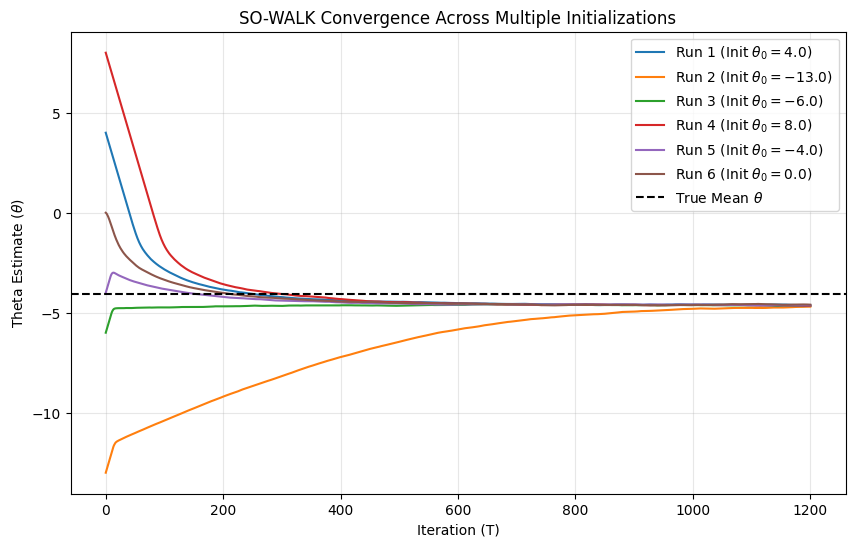

In [ ]:
#  Without parallelisation

# --- Experiment Parameters ---
T = 1000  # Outer steps 1200
B = 10               
M = 25 #40 
N = 70 #100 # Number of walkers


delta_step = 0.1    # Theta learning rate
b_scale = 1.0        # Laplace prior scale
gamma_val = 1 #0.99995

fig = plt.figure(figsize=(10, 6))
theta_walk = []
X_walk = []

thetas = [4.0, -13.0, -6.0, 8.0, -4.0, 0.0]

for run_idx in range(len(thetas)):
    # Randomly initialize theta0 between -15 and 10
    theta0_val = thetas[run_idx]
    th0 = np.array([[float(theta0_val)]])
    
    D = design_matrix.shape[1]
    #X0_M = np.random.normal(loc=theta0_val, scale=1.0, size=(D, N))
    x0_N = np.random.normal(0, 0.1, (D, N)) # Initialize x0_N with some slight noise
    
    th_list, x_values = so_walk_fast_decay( 
    log_p=log_p_laplace,
    th0=th0,
    x0_N=x0_N,
    y_l=design_matrix,
    y_f=labels,
    T=T,
    M=M,
    B=B,
    delta_step=delta_step,
    b=b_scale,
    gamma=gamma_val
    )
    
    # Extract flattened array of theta trajectory across iterations
    th_trajectory = np.array([t[0, 0] for t in th_list])
    
    theta_walk.append(th_trajectory)
    X_walk.append(x_values)
    
    # Plot trajectory for this run
    plt.plot(th_trajectory, label=f'Run {run_idx + 1} (Init $\\theta_0={theta0_val}$)')

# Reference line for ground truth mean
plt.axhline(y=np.mean(x_unknown), color='black', linestyle='dashed', label='True Mean $\\theta$')

plt.title('SO-WALK Convergence Across Multiple Initializations')
plt.xlabel('Iteration (T)')
plt.ylabel('Theta Estimate ($\\theta$)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()
fig.savefig('soul_WALK_convergence.pdf', format='pdf')

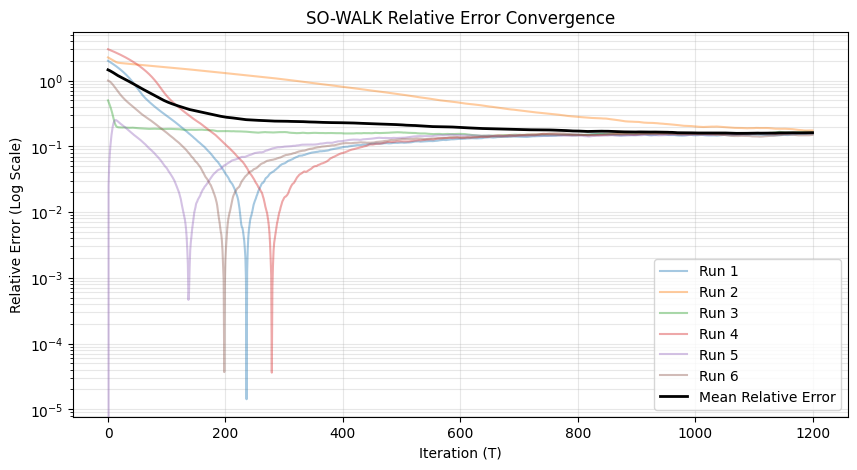

In [4]:
# Convert list of trajectories into a 2D numpy array of shape (num_runs, T + 1)
theta_walk_arr = np.array(theta_walk)

# Compute relative error trajectory for each run
relative_error_trajectories = np.abs(theta_walk_arr - theta_true) / np.abs(
    theta_true
)

# Mean relative error across all runs per iteration step
mean_relative_error_per_step = np.mean(relative_error_trajectories, axis=0)

# Plot Relative Error over iterations
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for idx, err_traj in enumerate(relative_error_trajectories):
    plt.plot(err_traj, alpha=0.4, label=f"Run {idx + 1}")

plt.plot(
    mean_relative_error_per_step,
    color="black",
    linewidth=2,
    label="Mean Relative Error",
)
plt.yscale("log")  # Log scale highlights convergence speed clearly
plt.title("SO-WALK Relative Error Convergence")
plt.xlabel("Iteration (T)")
plt.ylabel("Relative Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Errors with the same $\theta_0$

<Figure size 1000x600 with 0 Axes>

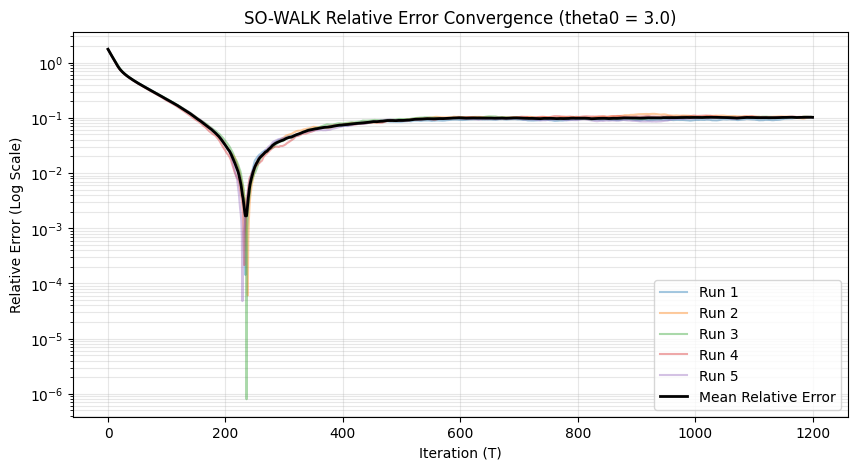

In [5]:
# --- Experiment Parameters ---
T = 1200  # Outer steps 
B = 10               
M = 40 
D = 50
N = 120

delta_step = 0.1    # Theta learning rate
b_scale = 1.0        # Laplace prior scale
gamma_val = 1 #0.99995

x0_N = np.random.normal(0, 0.1, (D, N)) # Initialize x0_N with some slight noise


fig = plt.figure(figsize=(10, 6))
theta_walk_same = []
X_walk_same = []

for run_idx in range(5):
    theta0_val = 3.0
    th0 = np.array([[float(theta0_val)]])
    
    D = design_matrix.shape[1]
    
    th_list, x_values = so_walk_fast_decay(
    log_p=log_p_laplace,
    th0=th0,
    x0_N=x0_N,
    y_l=design_matrix,
    y_f=labels,
    T=T,
    M=M,
    B=B,
    delta_step=delta_step,
    b=b_scale,
    gamma=gamma_val
    )
    
    # Extract flattened array of theta trajectory across iterations
    th_trajectory_same = np.array([t[0, 0] for t in th_list])
    
    theta_walk_same.append(th_trajectory_same)
    X_walk_same.append(x_values)
    

# Convert list of trajectories into a 2D numpy array of shape (num_runs, T + 1)
theta_walk_arr_same = np.array(theta_walk_same)

# Compute relative error trajectory for each run
relative_error_trajectories_same = np.abs(theta_walk_arr_same - theta_true) / np.abs(
    theta_true
)

# Mean relative error across all runs per iteration step
mean_relative_error_per_step_same = np.mean(relative_error_trajectories_same, axis=0)


plt.figure(figsize=(10, 5))
for idx, err_traj in enumerate(relative_error_trajectories_same):
    plt.plot(err_traj, alpha=0.4, label=f"Run {idx + 1}")

plt.plot(
    mean_relative_error_per_step_same,
    color="black",
    linewidth=2,
    label="Mean Relative Error",
)
plt.yscale("log")  # Log scale highlights convergence speed clearly
plt.title("SO-WALK Relative Error Convergence (theta0 = 3.0)")
plt.xlabel("Iteration (T)")
plt.ylabel("Relative Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Save data

In [6]:
# Save trajectories, ground truth, and precalculated errors
np.savez_compressed(
    "so_walk_results.npz",
    T=T,
    B=B,
    M=M,
    delta_step=delta_step,
    theta_true=theta_true,
    theta_walk_arr=theta_walk_arr,
    gamma_val = gamma_val,
    b_scale = b_scale,
    relative_error_trajectories=relative_error_trajectories,
    mean_relative_error_per_step=mean_relative_error_per_step,
    X_walk_same=X_walk_same,
    theta_walk_arr_same= theta_walk_arr_same,
    mean_relative_error_per_step_same  = mean_relative_error_per_step_same,
    relative_error_trajectories_same=relative_error_trajectories_same,

)

print("Data saved successfully to 'so_walk_results.npz'")

Data saved successfully to 'so_walk_results.npz'


# Load previous data

In [ ]:
# Load compressed data
data = np.load("so_walk_results.npz")

T = data["T"]
theta_true = data["theta_true"]
theta_walk_arr = data["theta_walk_arr"]
relative_error_trajectories = data["relative_error_trajectories"]
mean_relative_error_per_step = data["mean_relative_error_per_step"]

# Plot 1: Theta Convergence Trajectories ---
plt.figure(figsize=(10, 6))

for idx, th_trajectory in enumerate(theta_walk_arr):
    plt.plot(th_trajectory, alpha=0.7, label=f"Run {idx + 1}")

plt.axhline(
    y=theta_true,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=r"True $\theta$",
)

plt.title("SO-WALK Convergence Across Multiple Initializations", fontsize=14, pad=12)
plt.xlabel("Iteration ($T$)", fontsize=12)
plt.ylabel(r"Theta Estimate ($\theta$)", fontsize=12)
plt.legend(loc="upper right", frameon=True, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Plot 2: Relative Error Convergence (Log Scale) ---
plt.figure(figsize=(10, 5))

for idx, err_traj in enumerate(relative_error_trajectories):
    plt.plot(err_traj, alpha=0.3, label=f"Run {idx + 1}")

plt.plot(
    mean_relative_error_per_step,
    color="black",
    linewidth=2,
    label="Mean Relative Error",
)

plt.yscale("log")
plt.title("SO-WALK Relative Error Convergence", fontsize=14, pad=12)
plt.xlabel("Iteration ($T$)", fontsize=12)
plt.ylabel("Relative Error (Log Scale)", fontsize=12)
plt.legend(loc="upper right", frameon=True, fontsize=10)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()